In [115]:
# from jax.lib import xla_bridge
# import jax
# print(xla_bridge.get_backend().platform)
# # name = "cuDNN"
# jax._src.lib.cuda_versions.cudnn_get_version()
# # jax._src.lib.cuda_versions.cudnn_build_version()
# jax.default_device = jax.devices("gpu")[0]

# # # bp.math.set_platform("cpu")
# import os
# # if bp.math.get_platform() == 'cpu':
# threads = os.cpu_count()//10
# os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=' + str(threads)
# print(os.environ["XLA_FLAGS"])

In [116]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


In [ ]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Parameterizing by mass means the balance condition is independent of sigma
# zeta_e = (delta*omega_ie)/(gamma*omega_ee)
# zeta_i = (delta*omega_ii)/(gamma*omega_ei)

# * If delta == gamma (population size exactly balanced by synaptic weight), zeta balance
#   reduces to omega_ie == omega_ee and omega_ii == omega_ei

N_e = 2000
J_e = 0.0008 # Microsiemens
nu = 6.5
delta = 3.3
n_ext = 100

K_ee = 72
K_ie = 28
K_ei = 88
K_ii = 39

# N_e = 2000
# J_e = 0.0008 # Microsiemens
# delta = 3.3
# nu = 7
# n_ext = 100

# ? Notes:
# - A positive (real part) eigenvalue means the system is unstable
# - Two negative eigenvalues means excitatory bursts are immediately quenched
# - Two complex eigenvalue means oscillation (PING). More complex means sparser exc. activity?

# - Higher cross-coupling terms make the excitatory activity sparser, oscillations stronger
# - Increasing omega_ee does not increase the frequency of oscillations, just sharpens them
# - Increasing omega_ii sharpens the oscillations
#!- Increasing background drive increases frequency... makes sense, reduces recovery time of
#   exc. pop
# - Adaptation doesn't seem to induce theta oscillations without the spatial component... so
#   we should look at adding a central stimulus to the spatial model, like shencong.

# ! Exact frequency fo gamma oscillation depends on E and I timescales

# k = 0.7
# K_ee = 72*k
# K_ie = 28*k
# K_ei = 88*k
# K_ii = 39*k

# # * What are the eigenvalues of the weight matrix?
# W = np.array([[omega_ee, omega_ei], [-omega_ie*delta, -omega_ii*delta]]) # ! The presence of oscillations seems independent of delta? Just the strength is controlled by delta.
# tr = np.trace(W)
# eigvals = np.linalg.eigvals(W)
# det = np.linalg.det(W)
# frob = np.linalg.norm(W, ord='fro')
# print('Trace:', tr)
# print('Eigenvalues:', eigvals)
# print('Det:', det)
# print('Frobenius norm:', frob)

In [118]:
from src.models.Nonspatial import Nonspatial
from functools import partial

@partial(
    jax.jit,
    static_argnames=[
        "N_e",
    ],
)
def jittest(nu, J_e, delta, seed, N_e):
    NonspatialNet = Nonspatial(N_e = N_e,
        J_e = J_e, # Jaxable
        nu = nu, # Jaxable
        n_ext = n_ext,
        delta=delta, # Jaxable
        K_ee=K_ee,
        K_ei=K_ei,
        K_ie=K_ie,
        K_ii=K_ii,
        key=jax.random.PRNGKey(seed)) # Jaxable
    # * And simulate
    runner = bp.DSRunner(NonspatialNet, monitors=['E.spike'], numpy_mon_after_run=False)
    runner.run(duration=50.)
    return runner.mon['E.spike']


In [119]:
# out = jittest(300, 0.0001, 3.9, 49, 3000)
# out

In [120]:
from src.models.Nonspatial import Nonspatial
# import line_profiler

NonspatialNet = Nonspatial(N_e = N_e,
        J_e = J_e,
        nu = nu,
        n_ext = n_ext,
        delta=delta,
        K_ee=K_ee,
        K_ei=K_ei,
        K_ie=K_ie,
        K_ii=K_ii,
        key=jax.random.PRNGKey(42))

# %load_ext line_profiler
# %lprun -f NonspatialNet.__init__ build()

In [121]:
print("Num. Exc.:");print(np.prod(NonspatialNet.E.size))
print("Num. Inh.:");print(np.prod(NonspatialNet.I.size))
# thr_e, thr_i = NonspatialNet.nu_n_ext_thresh()
# print("Thresholds:");print(thr_e, thr_i)


Num. Exc.:
2000
Num. Inh.:
500


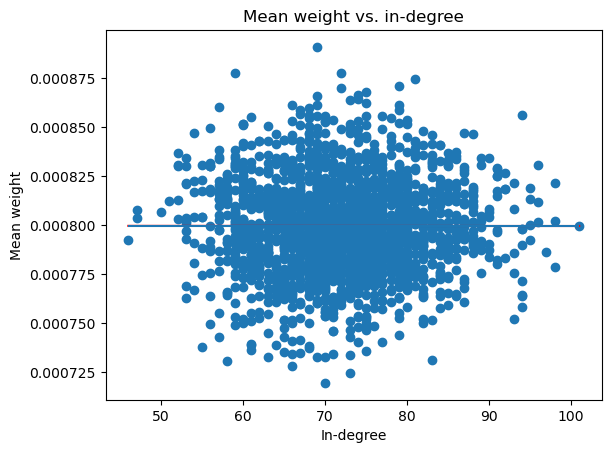

E2E in-degree: 72.0 (mean), 72.0 (expected)
E2I in-degree: 88.0 (mean), 88.0 (expected)
I2E in-degree: 28.0 (mean), 28.0 (expected)
I2I in-degree: 39.0 (mean), 39.0 (expected)
External in-degree (Exc.): 99.9 (mean)
External in-degree (Inh.): 99.2 (mean)


In [122]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(NonspatialNet.E2E.proj)
N = NonspatialNet.E2E.proj.post.size
ks = src.utils.indegrees_static(NonspatialNet.E2E.proj.comm.indices, N)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
mean_weight = np.mean(mean_ws)
plt.hlines(mean_weight, np.min(ks), np.max(ks))
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.utils.indegree(NonspatialNet.E2E.proj)
k_hat = NonspatialNet.expected_indegree("ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(NonspatialNet.E2I.proj)
k_hat = NonspatialNet.expected_indegree("ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(NonspatialNet.I2E.proj)
k_hat = NonspatialNet.expected_indegree("ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(NonspatialNet.I2I.proj)
k_hat = NonspatialNet.expected_indegree("ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")

# Print the mean number of external synapses
k_ext = src.utils.indegree(NonspatialNet.ext2E.proj)
print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
k_ext = src.utils.indegree(NonspatialNet.ext2I.proj)
print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")



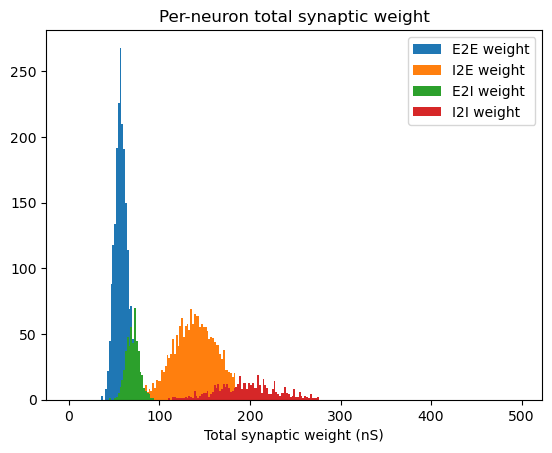

Sum of weights to average neuron:
E2E: 57.56912335589004 (nS)
E2I: 70.43116745143197 (nS)
I2E: 141.11179276928306 (nS)
I2I: 196.05181429744698 (nS)

Expected sum of weights to average neuron:
E2E: 57.60000000000001 (nS)
E2I: 70.4 (nS)
I2E: 141.12 (nS)
I2I: 196.56 (nS)

IE ratio (Exc.): 2.4511714708062438
IE ratio (Inh.): 2.7835945560982025

Expected IE ratio (Exc.): 2.45
Expected IE ratio (Inh.): 2.792045454545455


In [123]:
if True:
    # * Calculate the per-neuron EI balance
    # DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
    # ? How to properly check the balance of weights?
    I2E = bp.connect.csr2coo((NonspatialNet.I2E.proj.comm.indices, NonspatialNet.I2E.proj.comm.indptr))
    E2E = bp.connect.csr2coo((NonspatialNet.E2E.proj.comm.indices, NonspatialNet.E2E.proj.comm.indptr))
    E2I = bp.connect.csr2coo((NonspatialNet.E2I.proj.comm.indices, NonspatialNet.E2I.proj.comm.indptr))
    I2I = bp.connect.csr2coo((NonspatialNet.I2I.proj.comm.indices, NonspatialNet.I2I.proj.comm.indptr))
    w_I2E = NonspatialNet.I2E.proj.comm.weight
    w_E2E = NonspatialNet.E2E.proj.comm.weight
    w_E2I = NonspatialNet.E2I.proj.comm.weight
    w_I2I = NonspatialNet.I2I.proj.comm.weight
    assert len(I2E[0]) == len(w_I2E)

    Ne = np.prod(NonspatialNet.E.size)
    Ni = np.prod(NonspatialNet.I.size)
    bin_w_E2E = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
    bin_w_I2E = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
    bin_w_E2I = np.bincount(E2I[1], weights=w_E2I, minlength=Ni)
    bin_w_I2I = np.bincount(I2I[1], weights=w_I2I, minlength=Ni)
    bins = np.arange(0, 500, 2)
    plt.hist(bin_w_E2E*1000, bins=bins, label="E2E weight")
    plt.hist(bin_w_I2E*1000, bins=bins, label="I2E weight")
    plt.hist(bin_w_E2I*1000, bins=bins, label="E2I weight")
    plt.hist(bin_w_I2I*1000, bins=bins, label="I2I weight")
    plt.legend()
    plt.title("Per-neuron total synaptic weight")
    plt.xlabel("Total synaptic weight (nS)")
    plt.show()

    # plt.scatter(bin_w_E2E, bin_w_I2E)
    # plt.show()

    # plt.hist(bin_w_E2E/bin_w_I2E, bins=50)
    # plt.show()

    # * Print sum of weights in table
    print("Sum of weights to average neuron:")
    print("E2E:", np.mean(bin_w_E2E)*1000, "(nS)")
    print("E2I:", np.mean(bin_w_E2I)*1000, "(nS)")
    print("I2E:", np.mean(bin_w_I2E)*1000, "(nS)")
    print("I2I:", np.mean(bin_w_I2I)*1000, "(nS)")

    # * Print expected sum of weights
    print("")
    print("Expected sum of weights to average neuron:")
    print("E2E:", NonspatialNet.expected_sum_of_weights("ee")*1000, "(nS)")
    print("E2I:", NonspatialNet.expected_sum_of_weights("ei")*1000, "(nS)")
    print("I2E:", NonspatialNet.expected_sum_of_weights("ie")*1000, "(nS)")
    print("I2I:", NonspatialNet.expected_sum_of_weights("ii")*1000, "(nS)")


    # * Calculate an IE ratio for each population defined as the ratio of average total incoming
    #   inhibitory synaptic strength to average total incoming excitatory synaptic strength for
    #   a specific neuron type
    print("")
    IE_e, IE_i = NonspatialNet.calculate_zeta()
    print("IE ratio (Exc.):", IE_e)
    print("IE ratio (Inh.):", IE_i)

    print("")
    IE_e_hat, IE_i_hat = NonspatialNet.expected_zeta()
    print("Expected IE ratio (Exc.):", IE_e_hat)
    print("Expected IE ratio (Inh.):", IE_i_hat)
    w_E2E

In [124]:
# x = src.utils.draw_lognormal(0.1, 0.9, 100000000)
# # plt.hist(x, bins=50)
# # * Plot dist of x on loglog space
# logx = np.log10(x)
# plt.hist(logx, bins=5000)
# plt.xlabel("Log10(x)")
# plt.ylabel("Count")
# plt.title("Log-normal distribution of weights")
# plt.gca().set_yscale('log')
# plt.show()




In [125]:
idx_ee = NonspatialNet.E2E.proj.comm.indices
idx_ie = NonspatialNet.I2E.proj.comm.indices
idx_ei = NonspatialNet.E2I.proj.comm.indices
idx_ii = NonspatialNet.I2I.proj.comm.indices

iptr_ee = NonspatialNet.E2E.proj.comm.indptr
iptr_ie = NonspatialNet.I2E.proj.comm.indptr
iptr_ei = NonspatialNet.E2I.proj.comm.indptr
iptr_ii = NonspatialNet.I2I.proj.comm.indptr

w_ee = NonspatialNet.E2E.proj.comm.weight
w_ie = NonspatialNet.I2E.proj.comm.weight
w_ei = NonspatialNet.E2I.proj.comm.weight
w_ii = NonspatialNet.I2I.proj.comm.weight

N_e = np.prod(NonspatialNet.E.size)
N_i = np.prod(NonspatialNet.I.size)

In [126]:
# # ===== 0.  Grab τm from your BrainPy network ==========================
# # (rename `net` if your Nonspatial instance has another variable name)
# tau_e = NonspatialNet.E.C / NonspatialNet.E.g_L           # ms   e.g. 0.25 / 0.0167  ≈ 15
# tau_i = NonspatialNet.I.C / NonspatialNet.I.g_L           # ms   e.g. 0.25 / 0.025   ≈ 10

# # ===== 1.  Build SciPy CSR blocks (CPU) ===============================
# import numpy as np, scipy.sparse as sp, matplotlib.pyplot as plt
# from typing import Tuple, Dict

# def to_scipy_csr(indices, indptr, data, shape) -> sp.csr_matrix:
#     return sp.csr_matrix((data, indices, indptr), shape=shape, dtype=np.float32)

# E_E = to_scipy_csr(idx_ee, iptr_ee, w_ee, (N_e, N_e))
# E_I = to_scipy_csr(idx_ei, iptr_ei, w_ei, (N_e, N_i))
# I_E = to_scipy_csr(idx_ie, iptr_ie, w_ie, (N_i, N_e))
# I_I = to_scipy_csr(idx_ii, iptr_ii, w_ii, (N_i, N_i))

# # ===== 1 b.  Build diagonal leak matrices =============================
# D_e = sp.diags([-1.0 / tau_e] * N_e, format='csr')   # −1/τ_e on the diagonal
# D_i = sp.diags([-1.0 / tau_i] * N_i, format='csr')   # −1/τ_i on the diagonal

# # ===== 2.  Assemble full Jacobian (synapses + leak) ===================
# W_blocks = [[E_E + D_e,   E_I],          # excitatory rows
#             [-I_E,      -(I_I) + D_i]]  # inhibitory rows  (note extra minus)
# W_csr = sp.bmat(W_blocks, format='csr')
# N_tot = W_csr.shape[0]

# # ===== 3.  Sparse eigenspectrum (SciPy–CPU) ===========================
# from scipy.sparse.linalg import eigs

# def eigs_sparse(A, k=1000, which='LM', seed=0):
#     v0 = np.random.default_rng(seed).standard_normal(N_tot)
#     vals, vecs = eigs(A, k=k, which=which, tol=1e-6, maxiter=1000,
#                       v0=v0, return_eigenvectors=True)
#     return vals, vecs

# eigvals, eigvecs = eigs_sparse(W_csr, k=1000)   # complex eigenvalues

# # ===== 4.  Plot ========================================================
# plt.figure(figsize=(8, 8))
# plt.scatter(eigvals.real, eigvals.imag, s=5)
# plt.xlabel('Real part')
# plt.ylabel('Imaginary part')
# plt.title('Eigenvalue distribution (leak included)')
# plt.axhline(0, color='k', lw=1)
# plt.axvline(0, color='k', lw=1)
# plt.gca().set_aspect('equal')

# mean_eig = np.mean(eigvals[10:])        # skip the first few if you wish
# plt.scatter(mean_eig.real, mean_eig.imag, s=100, c='r', marker='x')
# plt.show()


In [127]:
# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights
bp.reset_state(NonspatialNet)
# * Simulate
# I = np.array(NonspatialNet.E.V.value)
# I[:] = 0.0
# i = I.reshape(*NonspatialNet.E.size)
# i[0:25, 0:25] = 0.0
duration = 5000.00
runner = bp.DSRunner(NonspatialNet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike','E.input', 'I.input'])# , inputs = [('Ein.input', I)])
runner.run(duration=duration)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 50000 steps: : 100%|██████████| 50000/50000 [00:10<00:00, 4662.22it/s]


In [128]:
def plot_trace_with_distribution(runner, neuron_idx=0, pop_type='E', n_bins=50, dt=25.0, figsize=(12, 6), cmap='binary'):
    """
    Plot a single neuron's voltage trace with a histogram distribution at each time step in the background.
    Uses JAX for fast histogram computation with temporal binning.

    Parameters:
    -----------
    runner : bp.DSRunner
        The runner object after simulation
    neuron_idx : int
        Index of the neuron to highlight with a trace
    pop_type : str
        'E' for excitatory neurons or 'I' for inhibitory neurons
    n_bins : int
        Number of voltage bins for the histogram
    dt : float
        Time bin size in ms - data points within this window will be combined
    figsize : tuple
        Size of the figure
    cmap : str
        Colormap for the histogram
    """
    import matplotlib.pyplot as plt
    import jax
    import jax.numpy as jnp
    import numpy as np

    fig, ax = plt.subplots(figsize=figsize)

    # Get the right population data and convert to JAX array
    if pop_type == 'E':
        V_full = jnp.asarray(runner.mon['E.V'])  # Shape should be (time_steps, n_neurons)
        title = f"Distribution of Excitatory Population Voltages (neuron #{neuron_idx} highlighted)"
    else:
        V_full = jnp.asarray(runner.mon['I.V'])  # For inhibitory population
        title = f"Distribution of Inhibitory Population Voltages (neuron #{neuron_idx} highlighted)"

    # Time points
    t_full = jnp.asarray(runner.mon.ts)

    # Apply temporal binning
    if dt > (t_full[1] - t_full[0]):
        # Calculate number of time points per bin
        points_per_bin = int(dt / (t_full[1] - t_full[0]))

        # Calculate number of bins needed
        n_bins_time = len(t_full) // points_per_bin
        if n_bins_time == 0:
            n_bins_time = 1  # At least one bin

        # Reshape the voltage data for binning
        # Only take complete bins
        V_reshaped = V_full[:n_bins_time*points_per_bin].reshape(n_bins_time, points_per_bin, -1)

        # Average within each time bin
        V = jnp.mean(V_reshaped, axis=1)

        # Create new time array with bin centers
        t_edges = t_full[:n_bins_time*points_per_bin:points_per_bin]
        if len(t_edges) > 1:
            bin_width = t_edges[1] - t_edges[0]
            t = t_edges + bin_width/2
        else:
            t = t_edges
    else:
        # No temporal binning needed
        V = V_full
        t = t_full

    # Find voltage range for consistent binning across all time steps
    v_min, v_max = jnp.min(V), jnp.max(V)
    bins = jnp.linspace(v_min, v_max, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Define JAX-compatible histogram function
    @jax.jit
    def compute_histogram(voltages):
        # Convert voltages to bin indices
        indices = jnp.clip(jnp.floor((voltages - v_min) / (v_max - v_min) * n_bins).astype(jnp.int32), 0, n_bins-1)
        # Count occurrences in each bin
        counts = jnp.zeros(n_bins, dtype=jnp.int32)
        counts = counts.at[indices].add(1)
        return counts

    # Vectorize the histogram computation over time steps
    compute_histograms = jax.vmap(compute_histogram)

    # Compute histograms for all time steps at once
    hist_data = compute_histograms(V)

    # Normalize each histogram row for better visibility
    hist_max = jnp.max(hist_data, axis=1, keepdims=True)
    hist_max = jnp.where(hist_max == 0, 1.0, hist_max)  # Avoid division by zero
    hist_norm = hist_data / hist_max

    # Convert back to numpy for matplotlib
    hist_norm = jnp.transpose(hist_norm).block_until_ready()

    # Plot the distribution over time as a 2D histogram/heatmap
    im = ax.pcolormesh(
        t,
        bin_centers,
        hist_norm,
        cmap=cmap,
        alpha=0.7
    )

    # Plot single neuron trace on top - use original high-resolution data for the trace
    ax.plot(t_full, V_full[:, neuron_idx], color='red', lw=1.5, label=f'Neuron {neuron_idx}')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Normalized Neuron Count')

    # Set labels and title
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane Potential (mV)')
    ax.set_title(f"{title} [dt={dt}ms]")
    ax.legend(loc='lower right')

    plt.tight_layout()
    return fig

Steady-state membrane potential (Exc.): -56.91592814371258
Steady-state membrane potential (Inh.): -60.62544
Mean membrane potential (Exc.): -58.776234
Mean membrane potential (Inh.): -59.495796


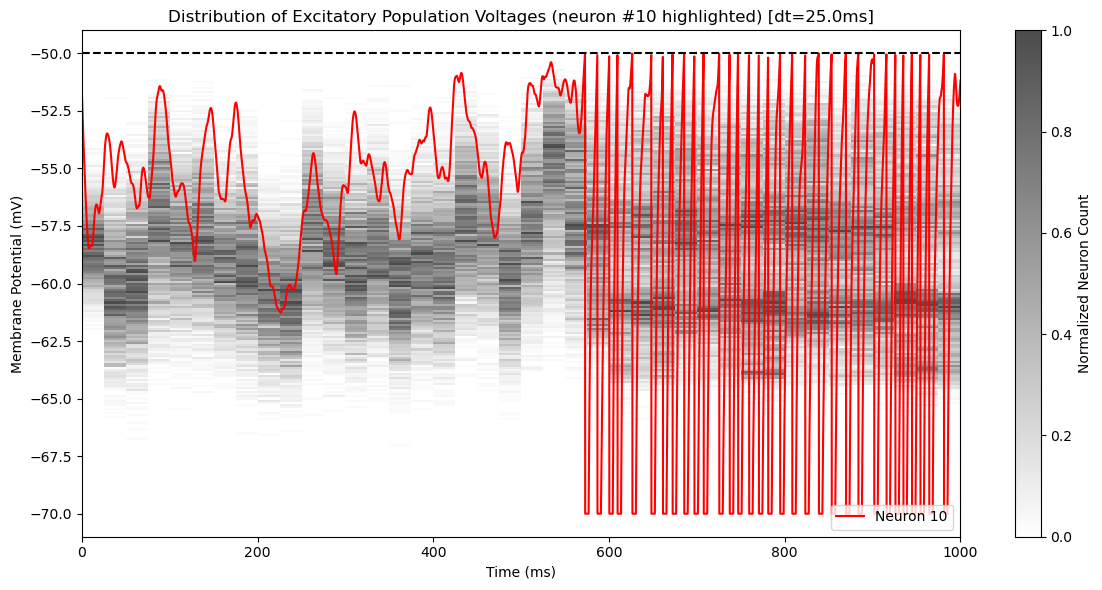

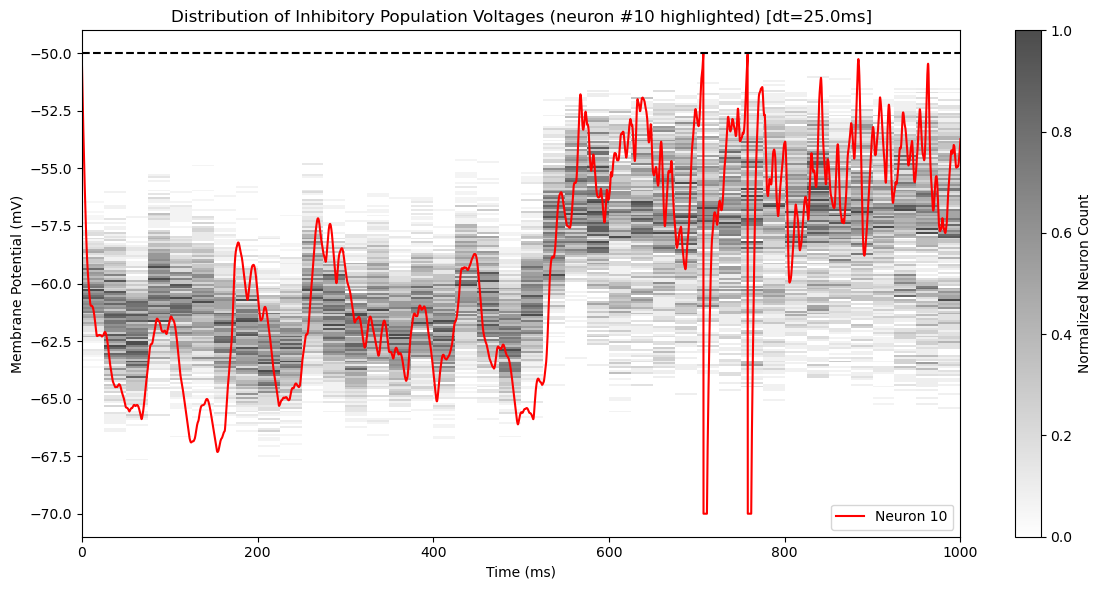

In [129]:
ve, vi = NonspatialNet.subthreshold_equilibrium_potential()
print("Steady-state membrane potential (Exc.):", ve)
print("Steady-state membrane potential (Inh.):", vi)
mve = np.mean(runner.mon['E.V'])
mvi = np.mean(runner.mon['I.V'])
print("Mean membrane potential (Exc.):", mve)
print("Mean membrane potential (Inh.):", mvi)

# Plot the distribution over time for excitatory population with neuron #10 highlighted
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='E', n_bins=200)
plt.gca().set_xlim(0, 1000)
thr_e = NonspatialNet.E.V_th
plt.axhline(thr_e, color='black', linestyle='--', lw=1.5)
# Add dashed lines showing threshold

# Plot for inhibitory population
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='I', n_bins=200)
plt.gca().set_xlim(0, 1000)
thr_i = NonspatialNet.I.V_th
plt.axhline(thr_i, color='black', linestyle='--', lw=1.5)


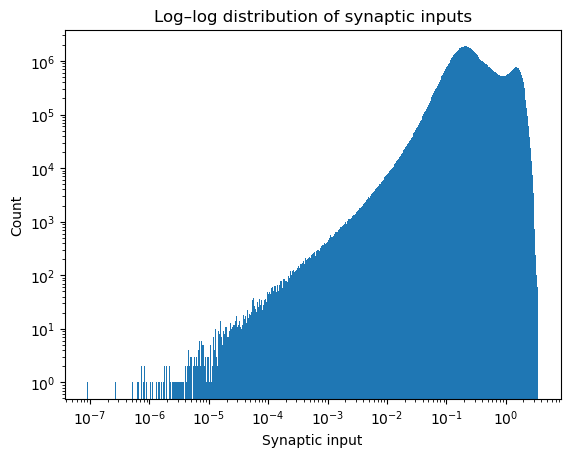

In [130]:
# Log–log histogram of excitatory synaptic inputs
x = np.asarray(runner.mon['E.input']).flatten()
# keep only positive values to avoid log(0)
x = x[x > 0]
# set up log‑spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
plt.hist(x, bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Synaptic input")
plt.ylabel("Count")
plt.title("Log–log distribution of synaptic inputs")
plt.show()


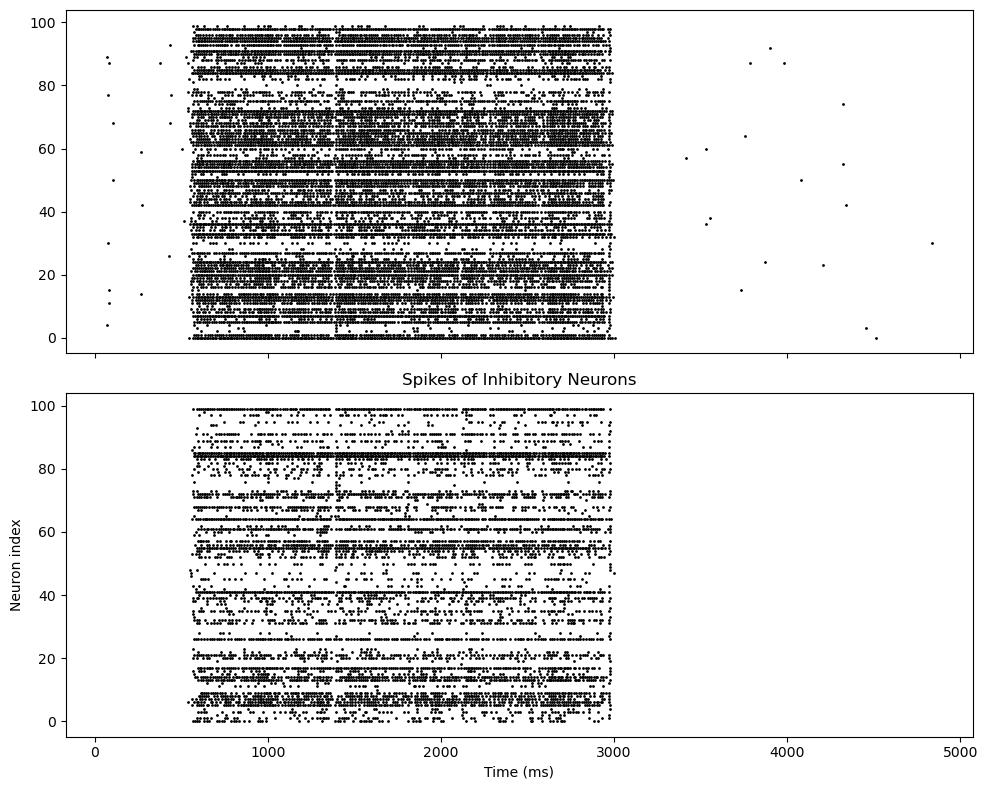

In [131]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::20],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
plt.show()

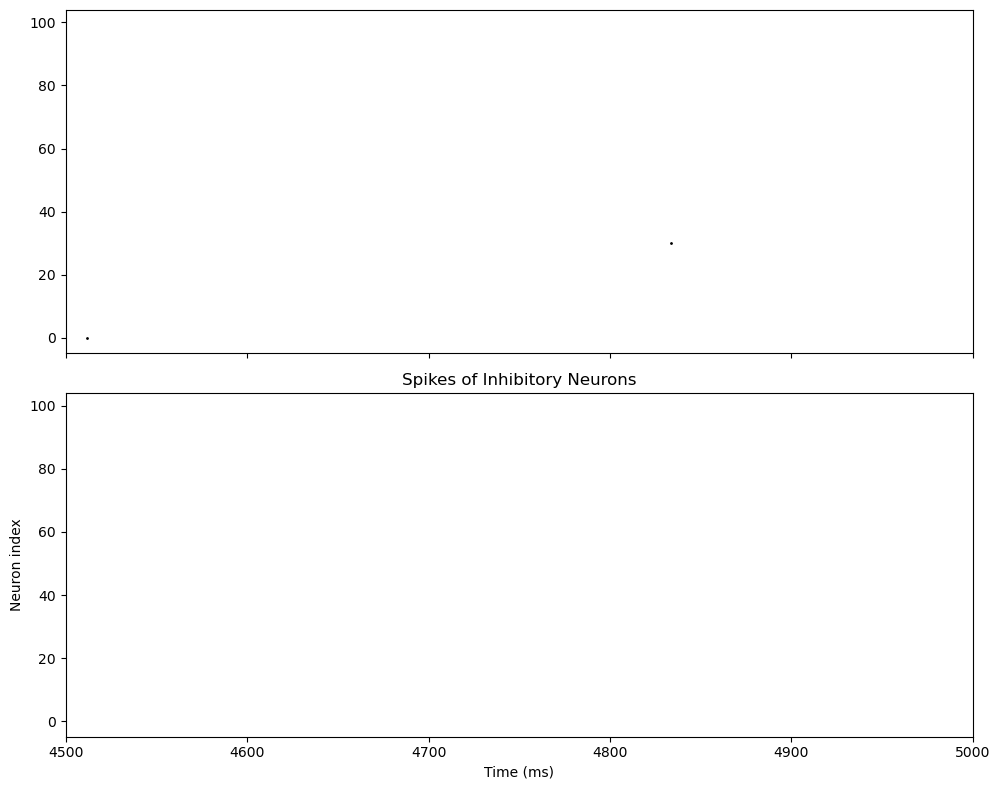

In [132]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::20],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
axs[0].set_xlim(4500, 5000)
axs[1].set_xlim(4500, 5000)
plt.show()

σ̂  (>1 Hz only) = 1.015


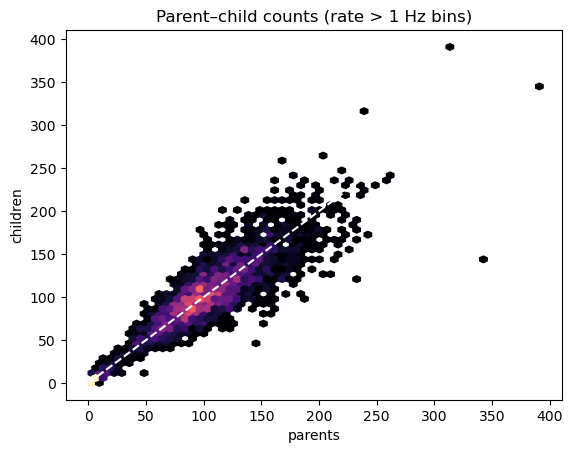

In [133]:
bin_ms   = 1                       # 1‑ms bins
dt       = runner.dt
steps    = int(bin_ms / dt)

# ----- spike counts per simulation step -------------------------------
pop_step = runner.mon['E.spike'].sum(axis=1) \
         + runner.mon['I.spike'].sum(axis=1)

# ----- bin into 1‑ms windows ------------------------------------------
n_bins = pop_step.size // steps
n      = pop_step[:n_bins*steps].reshape(n_bins, steps).sum(axis=1)

# ----- mask: keep only bins whose rate > 1 Hz --------------------------
N_tot  = NonspatialNet.E.num + NonspatialNet.I.num
rate   = 1000.0 * n / N_tot           # Hz per neuron in that bin
mask   = rate > 1.0                   # Boolean

# parents / children restricted to high‑rate periods
parents  = n[:-1][mask[:-1]]          # parent bin must be high‑rate
children = n[1:][mask[:-1]]           # same indices shifted by +1

# simple branching ratio
sigma_hat = (children[parents > 0] / parents[parents > 0]).mean()
print(f"σ̂  (>1 Hz only) = {sigma_hat:.3f}")

# ----- scatter plot ----------------------------------------------------
plt.hexbin(parents, children, gridsize=60, mincnt=1, cmap='magma')
lim = max(parents.max(), children.max())
plt.plot([0, lim], [0, lim], 'w--')
plt.xlabel('parents'); plt.ylabel('children')
plt.title('Parent–child counts (rate > 1 Hz bins)')
plt.show()

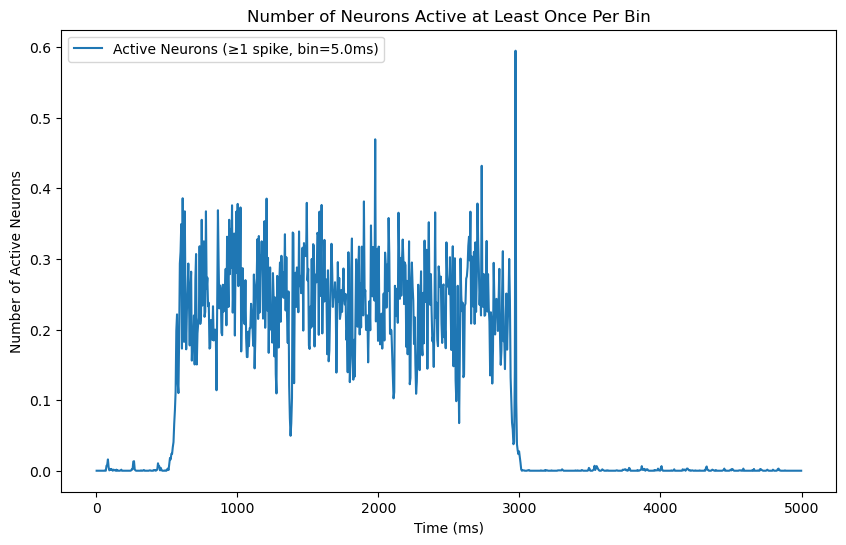

In [134]:
# * Produce a plot of the number of neurons active at any given point in time

time = runner.mon["ts"]
spikes = runner.mon["E.spike"]  # shape: (time_steps, num_neurons), 1 if neuron spiked, else 0

bin_size = 5.0
time_ix = jnp.floor((time - time[0]) / bin_size).astype(int)
unique_bins = jnp.arange(time_ix.min(), time_ix.max() + 1)

binned_time = []
binned_active = []

for b in unique_bins:
    bin_mask = (time_ix == b)
    # Determine which neurons spiked at least once in this bin
    active_in_bin = jnp.any(spikes[bin_mask], axis=0)
    # Count how many neurons were active
    active_count = jnp.sum(active_in_bin)
    # Average time in this bin
    avg_t = jnp.mean(time[bin_mask])

    binned_time.append(avg_t)
    binned_active.append(active_count)

binned_time = jnp.array(binned_time)
binned_active = jnp.array(binned_active)
binned_prop_active = binned_active / spikes.shape[1]  # Normalize by number of neurons

plt.figure(figsize=(10, 6))
plt.plot(binned_time, binned_prop_active, label=f"Active Neurons (≥1 spike, bin={bin_size}ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Number of Active Neurons")
plt.title("Number of Neurons Active at Least Once Per Bin")
plt.legend()
plt.show()



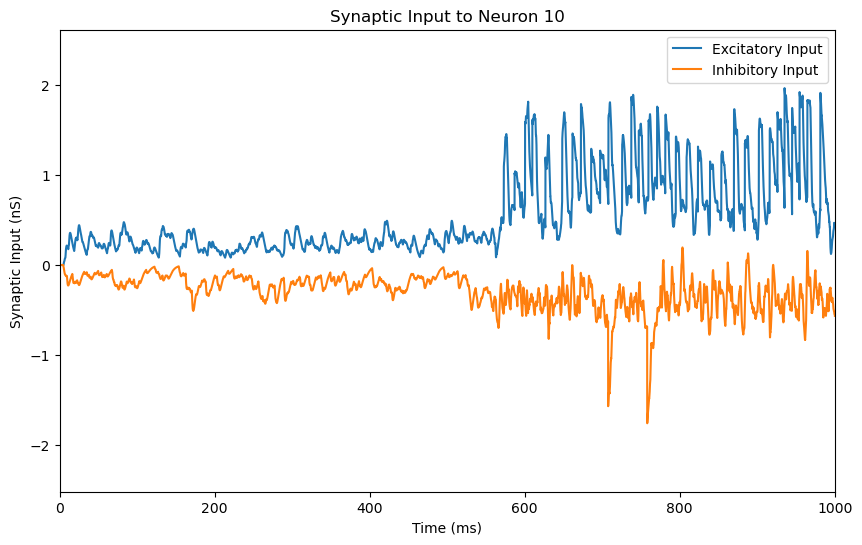

In [135]:
# * Plot synaptic input for a sample neuron
n = 10
Ein = runner.mon['E.input'][:, n]
Iin = -runner.mon['I.input'][:, n]

plt.figure(figsize=(10, 6))
plt.plot(runner.mon.ts, Ein, label='Excitatory Input')
plt.plot(runner.mon.ts, Iin, label='Inhibitory Input')
plt.xlabel("Time (ms)")
plt.ylabel("Synaptic Input (nS)")
plt.title(f"Synaptic Input to Neuron {n}")
plt.legend()
plt.gca().set_xlim(0, 1000)
plt.show()


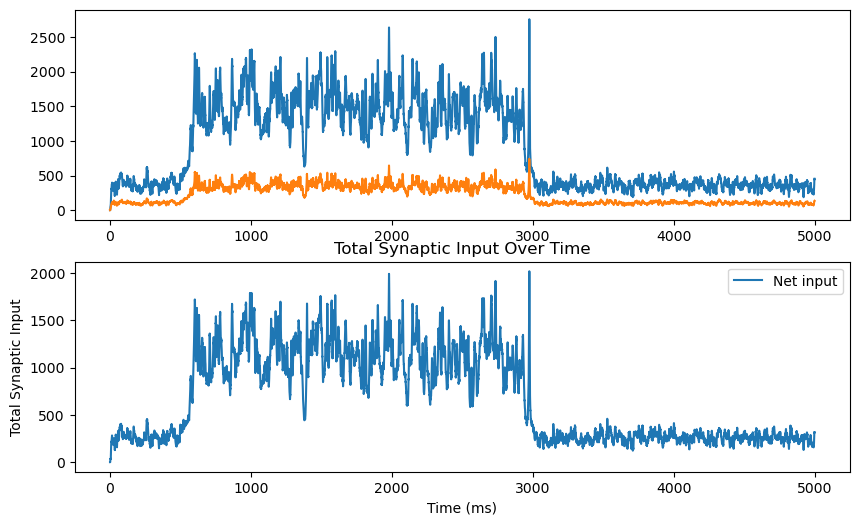

In [136]:
# * Plot the sum of synaptic input across time

Ein = runner.mon['E.input']
Iin = runner.mon['I.input']
Einput = jnp.sum(Ein, axis=1)
Iinput = jnp.sum(Iin, axis=1)
input = Einput - Iinput
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(runner.mon.ts, Einput, label='E input')
plt.plot(runner.mon.ts, Iinput, label='I input')
plt.subplot(2, 1, 2)
plt.plot(runner.mon.ts, input, label='Net input')
plt.xlabel("Time (ms)")
plt.ylabel("Total Synaptic Input")
plt.title("Total Synaptic Input Over Time")
plt.legend()
plt.show()


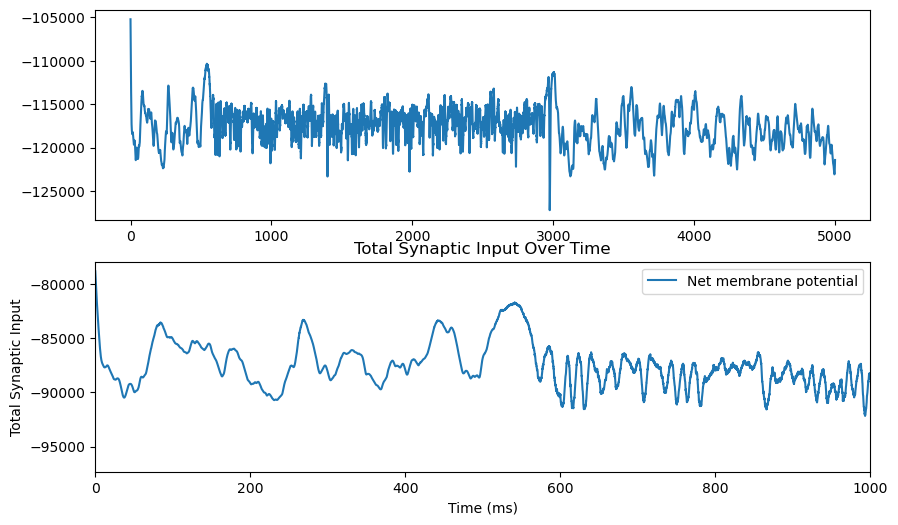

In [137]:
# * Plot the sum of membrane potentials for exc and inh pops
Ein = runner.mon['E.V']
Iin = runner.mon['I.V']
Einput = jnp.sum(Ein, axis=1)
Iinput = jnp.sum(Iin, axis=1)
input = Einput - Iinput
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(runner.mon.ts, Einput, label='E membrane potential')
# plt.plot(runner.mon.ts, Iinput, label='I membrane potential')
plt.subplot(2, 1, 2)
plt.plot(runner.mon.ts, input, label='Net membrane potential')
plt.xlabel("Time (ms)")
plt.ylabel("Total Synaptic Input")
plt.title("Total Synaptic Input Over Time")
plt.legend()
plt.gca().set_xlim(0, 1000)
plt.show()


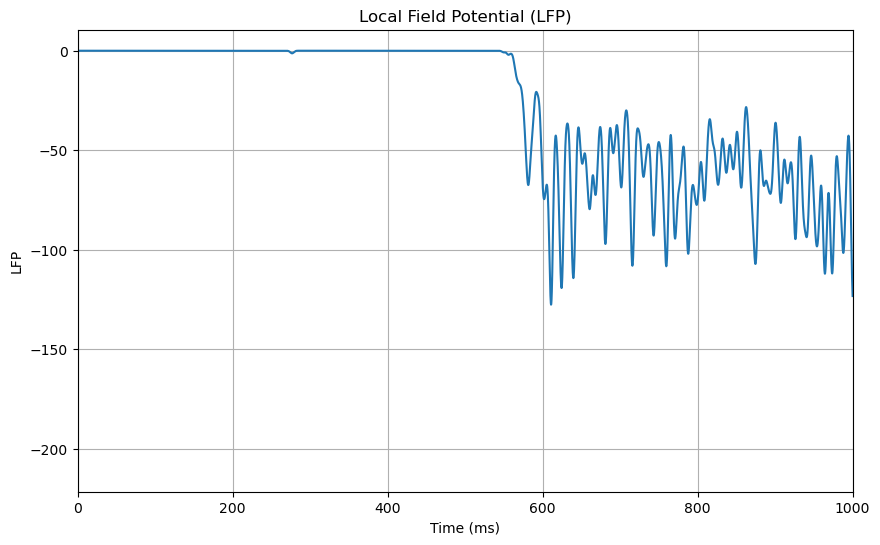

In [138]:
from scipy.signal import welch
from scipy.signal.windows import hann

# ! This LFP can introduce gamma oscillations when summing exc. and inh. LFP, due to slgiht
# time delay in inhibitory response.

# * Start by summing the spikes in dt = 25ms bins
t = runner.mon['ts'].view()
# dt = 10.0
# n_bins = int(t[-1] / dt)
# allspikes = bp.math.sum(runner.mon['E.spike'], axis=1)

# # Group allspikes into dt ms bins, then sum in those bins
# bin_indices = (t / dt).astype(int)
# bin_indices = jnp.clip(bin_indices, 0, n_bins - 1)  # Ensure we stay within bounds
# spikes_binned = jnp.bincount(bin_indices, weights=allspikes, length=n_bins)

lfp = bp.measure.unitary_LFP(t, runner.mon['I.spike'].view(), 'inh', location='superficial layer')
# lfp = bp.measure.unitary_LFP(t, runner.mon['E.spike'].view(), 'exc', location='superficial layer')

# t_binned = jnp.arange(0, n_bins) * dt
# lfp = jnp.convolve(spikes_binned, hann(100), mode='same')
 # * Plot 'LFP'
plt.figure(figsize=(10, 6))
# plt.plot(spikes_binned)
plt.plot(t, lfp)
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.title('Local Field Potential (LFP)')
plt.grid(True)
plt.gca().set_xlim(0, 1000)
plt.show()



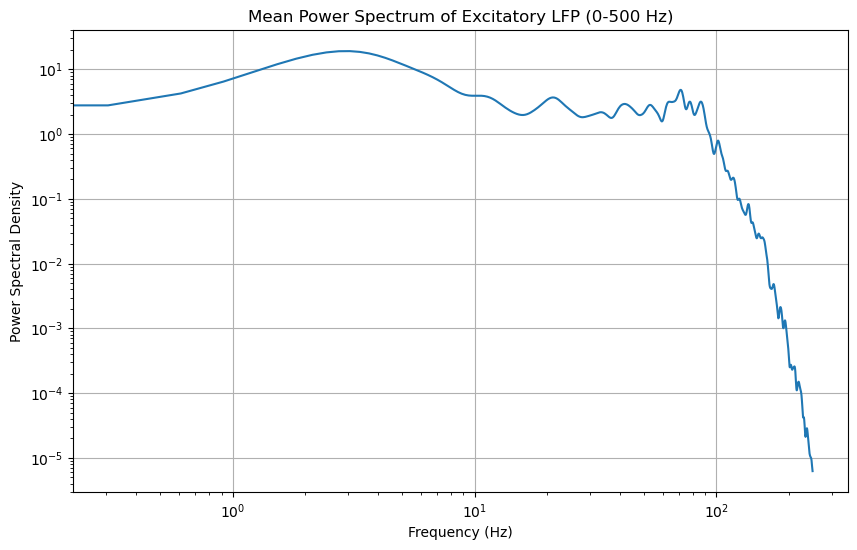

In [139]:
# * Plot the mean power spectrum.
# Calculate a spectrum for each neuron, then average it

ts = t / 1000  # To seconds

lfp = lfp - np.mean(lfp, axis=0)
# lfp = binned_prop_active
# lfp = input

f, Pxx = welch(lfp, fs=1/(ts[1] - ts[0]), nperseg=4000, nfft=2048*16)

# Limit frequency range to 500 Hz
freq_mask = f <= 250
f_limited = f[freq_mask]
Pxx_limited = Pxx[freq_mask]

plt.figure(figsize=(10, 6))
plt.loglog(f_limited, Pxx_limited)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Mean Power Spectrum of Excitatory LFP (0-500 Hz)')
plt.grid(True)
plt.show()

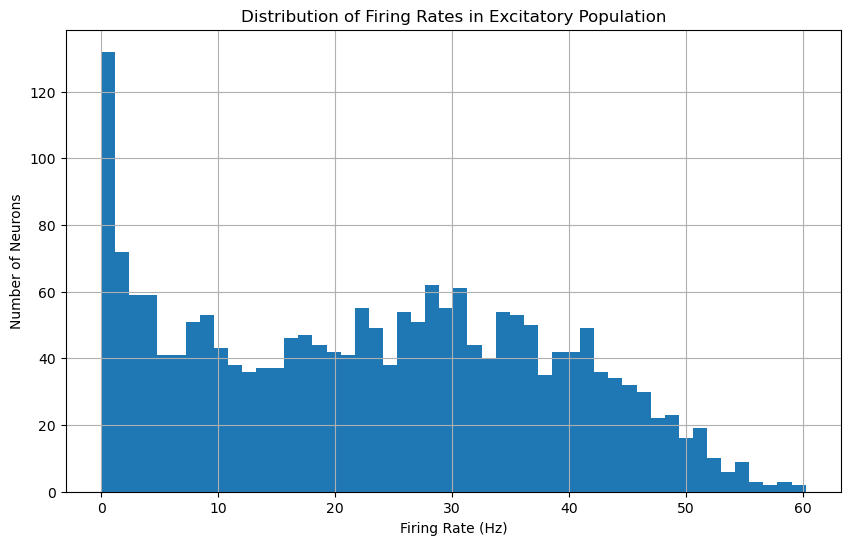

In [140]:
# * Plot the distribution of firing rates by summing the total numebr of spikes over the
#   recording, divided byt he length of the recording
spikes = runner.mon['E.spike']
t = runner.mon['ts'].view()
T = t[-1] / 1000  # Duration in seconds
rates = np.sum(spikes, axis=0) / T

plt.figure(figsize=(10, 6))
plt.hist(rates, bins=50)
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Firing Rates in Excitatory Population')
plt.grid(True)
plt.show()


In [141]:

#! Uncomment to run, but takes a while
# nu_n_ext = range(1, 601, 10)
# out = NonspatialNet.estimate_filter_factor(nu_n_ext = nu_n_ext)

NameError: name 'nu_n_ext' is not defined

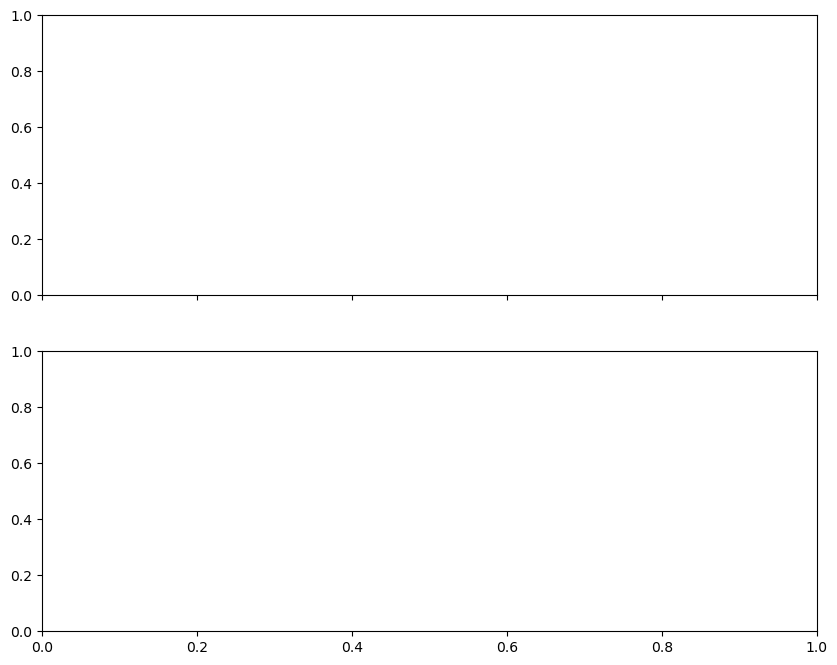

In [142]:
# * Plot membrane potential (and SD as a band) as a function of nu*n_ext, for exc and inh in
#   different subplots
alpha = 0.1
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
axs[0].plot(nu_n_ext, out['E']['mean'], label='Excitatory')
# * Add a light line either side of the mean for pm the first SD
axs[0].fill_between(nu_n_ext, out['E']['mean'] - out['E']['std'], out['E']['mean'] + out['E']['std'], alpha=0.1, color='cornflowerblue')
# * And another band for the 2nd sd, same color
axs[0].fill_between(nu_n_ext, out['E']['mean'] - 2*out['E']['std'], out['E']['mean'] + 2*out['E']['std'], alpha=0.1, color='cornflowerblue')
#and another for 3 SD
axs[0].fill_between(nu_n_ext, out['E']['mean'] - 3*out['E']['std'], out['E']['mean'] + 3*out['E']['std'], alpha=0.1, color='cornflowerblue')
# Add fainter grid lines (fainter than default)
axs[0].grid(True)
#Make grid lines fainter
axs[0].grid(alpha=alpha*2)

axs[0].set_title("Mean Membrane Potential")
axs[0].set_ylabel("Membrane Potential (mV)")
axs[0].legend()
# addd line for threshold
axs[0].axhline(NonspatialNet.E.V_th, color='black', linestyle='--', lw=1.5)

axs[1].plot(nu_n_ext, out['I']['mean'], label='Inhibitory', color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - out['I']['std'], out['I']['mean'] + out['I']['std'], alpha=0.1, color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - 2*out['I']['std'], out['I']['mean'] + 2*out['I']['std'], alpha=0.1, color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - 3*out['I']['std'], out['I']['mean'] + 3*out['I']['std'], alpha=0.1, color='crimson')
axs[1].grid(True)
axs[1].grid(alpha=alpha*2)

axs[1].set_xlabel("nu*n_ext")
axs[1].set_ylabel("Membrane Potential (mV)")
axs[1].legend()
axs[1].axhline(NonspatialNet.I.V_th, color='black', linestyle='--', lw=1.5)

plt.tight_layout()
plt.show()


In [ ]:
# * Do a linear regression to estimate the slope
from scipy.stats import linregress
m_e, b_e, r_e, p_e, se_e = linregress(nu_n_ext, out['E']['mean'])
print("Excitatory slope:", m_e)
m_i, b_i, r_i, p_i, se_i = linregress(nu_n_ext, out['I']['mean'])
print("Inhibitory slope:", m_i)

alpha_e = m_e / (NonspatialNet.J_e / NonspatialNet.E.g_L)
print("Excitatory filter factor:", alpha_e)
alpha_i = m_i / (NonspatialNet.J_e / NonspatialNet.I.g_L)
print("Inhibitory filter factor:", alpha_i)
